### **Autor:** David Roca Tauste
---

# 📌 **ACTIVIDAD 3: CLASIFICADOR K-NN**
---

## PASO 1: CARGA DE DATOS Y CREACIÓN DEL MODELO

### a) Copia el fichero saa_u02_p04_a2_<tus_iniciales>.ipynb en el fichero saa_u02_p04_a3_<tus_iniciales>.ipynb para cargar los datos de manera similar a como lo hiciste antes y completa el resto de apartados. Cuando particiones los datos y realices otras operaciones aleatorias vuelve a utilizar una semilla aleatoria que coincida con la longitud de tu nombre concatenada a la de tu primer apellido y concatenada a la de tu segundo apellido.

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df_vino = pd.read_csv("wine.csv", header=None)

df_vino.columns = [
    "Class",
    "Alcohol",
    "Ácido Málico",
    "Posos",
    "Alcalinidad de posos",
    "Magnesio",
    "Total Fenoles",
    "Flavanoides",
    "No flavanoides fenoles",
    "Proanticianinas",
    "Intensidad Color",
    "Saturación",
    "OD280/OD315 de vinos diluidos",
    "Prolina",
]

print("Clases", np.unique(df_vino["Class"]))
print(df_vino.head())

# Dividir en train + test
X, y = df_vino.iloc[:, 1:].values, df_vino.iloc[:, 0].values

semilla = 546
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=semilla
)

Clases [1 2 3]
   Class  Alcohol  Ácido Málico  Posos  Alcalinidad de posos  Magnesio  \
0      1    14.23          1.71   2.43                  15.6       127   
1      1    13.20          1.78   2.14                  11.2       100   
2      1    13.16          2.36   2.67                  18.6       101   
3      1    14.37          1.95   2.50                  16.8       113   
4      1    13.24          2.59   2.87                  21.0       118   

   Total Fenoles  Flavanoides  No flavanoides fenoles  Proanticianinas  \
0           2.80         3.06                    0.28             2.29   
1           2.65         2.76                    0.26             1.28   
2           2.80         3.24                    0.30             2.81   
3           3.85         3.49                    0.24             2.18   
4           2.80         2.69                    0.39             1.82   

   Intensidad Color  Saturación  OD280/OD315 de vinos diluidos  Prolina  
0              5.64  

### b) Continuamos usando un objeto multiclass.OneVsRestClassifier() para que utilice el método uno contra el resto y ahora un modelo de clasificación de tipo neighbors.NeighborsClassifier con el valor de k (parámetro n_neighbors) que prefieras. Borra el código que imprime los parámetros de las líneas de los modelos de regresión porque k vecinos cercanos no usa línea (borra el apartado c) anterior).

In [3]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier

k = 5

# Modelo OneVsRestClassifier con KNeighborsClassifier
modelo_ovr = OneVsRestClassifier(KNeighborsClassifier(n_neighbors=k))

### c) Entrena el modelo y muestra los valores de la matriz de confusión y las métricas de eficiencia o alternativamente un informe de clasificación donde aparezcan tanto para los datos de train como para los datos de test.

In [4]:
from sklearn.metrics import classification_report, confusion_matrix

# Entrenar modelo
modelo_ovr.fit(X_train, y_train)
print("Clasificadores individuales:", modelo_ovr.estimators_)

# Predicciones
y_pred = modelo_ovr.predict(X_test)

# Matriz de confusión
matriz = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:")
print(matriz)

# Métricas de eficiencia
clases = np.unique(y_test).astype(str)
reporte = classification_report(y_test, y_pred, target_names=clases)
print("\nInforme de clasificación:\n", reporte)

Clasificadores individuales: [KNeighborsClassifier(), KNeighborsClassifier(), KNeighborsClassifier()]

Matriz de confusión:
[[ 8  1  1]
 [ 1 17  4]
 [ 1 15  6]]

Informe de clasificación:
               precision    recall  f1-score   support

           1       0.80      0.80      0.80        10
           2       0.52      0.77      0.62        22
           3       0.55      0.27      0.36        22

    accuracy                           0.57        54
   macro avg       0.62      0.62      0.59        54
weighted avg       0.58      0.57      0.55        54



### d) Muestra la curva ROC y el valor AUC de cada clase y del modelo en global en los datos de test. Para hacerlo ten en cuenta que ahora este modelo no implementa la función decision_function() así que tendremos que utilizar predict_proba().

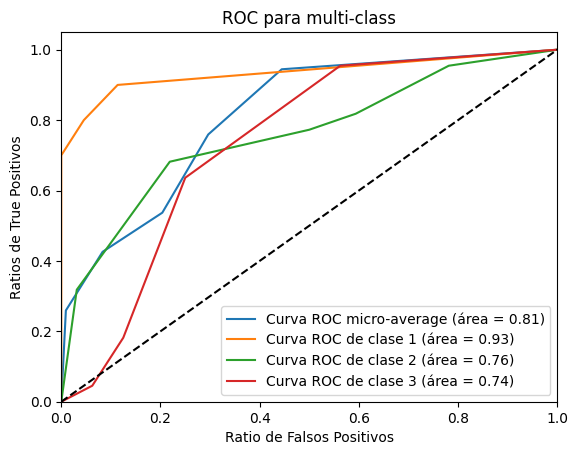

In [5]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

fpr = dict()
tpr = dict()
roc_auc = dict()

clases = df_vino["Class"].unique()  # Diferentes clases: diferentes valores de Class
n_clases = clases.shape[0]  # Cantidad de clases diferentes

y_test_bin = label_binarize(y_test, classes=[1, 2, 3])  # Binarizar el test
y_score = modelo_ovr.predict_proba(X_test)  # Distancia a cada clase

for i in range(n_clases):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())  # micro-medias ROC y AUC
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Dibujar la curva ROC
plt.figure()
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="Curva ROC micro-average (área = {0:0.2f})".format(roc_auc["micro"]),
)
for i in range(n_clases):
    plt.plot(
        fpr[i],
        tpr[i],
        label="Curva ROC de clase {0} (área = {1:0.2f})".format(clases[i], roc_auc[i]),
    )

plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Ratio de Falsos Positivos")
plt.ylabel("Ratios de True Positivos")
plt.title("ROC para multi-class")
plt.legend(loc="lower right")
plt.show()

### e) Responde a la vista de los resultados de los apartados d) y e) ¿Generaliza bien o tiene overfitting?
El modelo parece que tiene overfitting, debido a que tiene un AUC considerablemente más alto que la accuracy. Además, se puede ver que está sobreajustado especialmente a la clase 1 porque sus resultados son bastante mejores que con el resto de clases.

---
## PASO 2: MEJORA DEL MODELO CON SBS

### g) Aunque está implementado en scikit-learn, como es sencillo de hacer lo vamos a progrmar nosotros. Así que manos a la obra, crea el fichero sbs_<tus_iniciales>.py y copia el siguiente código:

In [6]:
from sbs_davroctau import SBS

knn = KNeighborsClassifier(n_neighbors=5)
sbs = SBS(knn, k_features=1)
sbs.fit(X_train, y_train)

### h) Como el objeto sbs ha ido coleccionando los scores de cada etapa, podemos graficar la evolución a medida que va quitando características. Adapta el siguiente código y lo añades a tu fichero (ten en cuenta que estás usando el objeto multiclase) y cuando lo ejecutes, a la vista del gráfico, ¿En qué rango de características funciona bien el modelo [desde, hasta]?

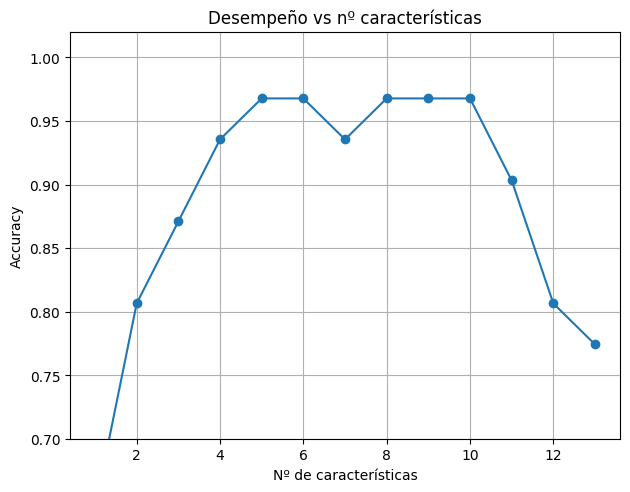

In [7]:
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5)
sbs = SBS(knn, k_features=1)    # Le pedimos que pruebe hasta dejar solo 1
sbs.fit(X_train, y_train)

# Dibujamos como cambia el desempeño al cambiar el nº de características
k_carac = [len(k) for k in sbs.subsets_]

plt.plot(k_carac, sbs.scores_, marker='o')
plt.ylim([0.7, 1.02])
plt.ylabel('Accuracy')
plt.xlabel('Nº de características')
plt.grid()
plt.tight_layout()
plt.title("Desempeño vs nº características")
plt.show()

El modelo funciona bien desde la utilización de 5 hasta 10 características, con una accuracy mayor de 0'95. Excepto para una cantidad de 7, que desciende por debajo de 0'95. 

### i) Si al clasificador KNN le afectan cosas, intenta minimizar estas cosas antes de realizar la división en train + test. Además, por prudencia (porque nos está dando una medida del desempeño agrupado en las 3 clases) vamos a quedarnos con la cantidad de características mayor que tenga un mejor desempeño, es decir, si entre [1, 4] tiene buen desempeño, nos quedamos con 4 en vez de con 1 por si a alguna clase le afecta demasiado no tener alguna de las que descartemos, pero esa pérdida se enmascara con buenos resultados en las otra clases. Así que nos quedaríamos con 4. Pero es necesario saber qué características son esas. Si adaptas este código en el que veríamos qué puedes saberlo suponiendo que hay 13 y queremos quedarnos con 3:

In [8]:
k3 = list(sbs.subsets_[10])
print(df_vino.columns[1:][k3])

Index(['Alcohol', 'Ácido Málico', 'Proanticianinas'], dtype='object')


### j) Ahora crea un nuevo clasificador pero descartando las categorías que el método anterior te indique que son descartables. Puedes adaptar el ejemplo. Calcula matriz, e informe de clasificación para train y test (mira si generaliza) y la curva ROC. Compara el desempeño de los dos modelos. ¿Hay diferencias significativas?

In [9]:
knn.fit(X_train[:, k3], y_train)

KNeighborsClassifier()

In [10]:
# Predicciones
X_test = X_test[:, k3]
y_pred = knn.predict(X_test)

# Matriz de confusión
matriz = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:")
print(matriz)

# Métricas de eficiencia
clases = np.unique(y_test).astype(str)
reporte = classification_report(y_test, y_pred, target_names=clases)
print("\nInforme de clasificación:\n", reporte)


Matriz de confusión:
[[ 9  0  1]
 [ 0 19  3]
 [ 4  2 16]]

Informe de clasificación:
               precision    recall  f1-score   support

           1       0.69      0.90      0.78        10
           2       0.90      0.86      0.88        22
           3       0.80      0.73      0.76        22

    accuracy                           0.81        54
   macro avg       0.80      0.83      0.81        54
weighted avg       0.82      0.81      0.82        54



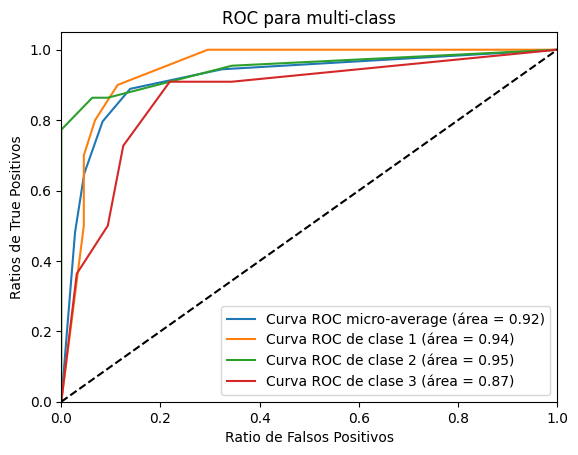

In [11]:
clases = df_vino["Class"].unique()  # Diferentes clases: diferentes valores de Class
n_clases = clases.shape[0]  # Cantidad de clases diferentes

y_test_bin = label_binarize(y_test, classes=[1, 2, 3])  # Binarizar el test
y_score = knn.predict_proba(X_test)  # Distancia a cada clase

for i in range(n_clases):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())  # micro-medias ROC y AUC
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Dibujar la curva ROC
plt.figure()
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="Curva ROC micro-average (área = {0:0.2f})".format(roc_auc["micro"]),
)
for i in range(n_clases):
    plt.plot(
        fpr[i],
        tpr[i],
        label="Curva ROC de clase {0} (área = {1:0.2f})".format(clases[i], roc_auc[i]),
    )

plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Ratio de Falsos Positivos")
plt.ylabel("Ratios de True Positivos")
plt.title("ROC para multi-class")
plt.legend(loc="lower right")
plt.show()

### RESUMEN

**Modelo 1: Matriz e informe**<br>
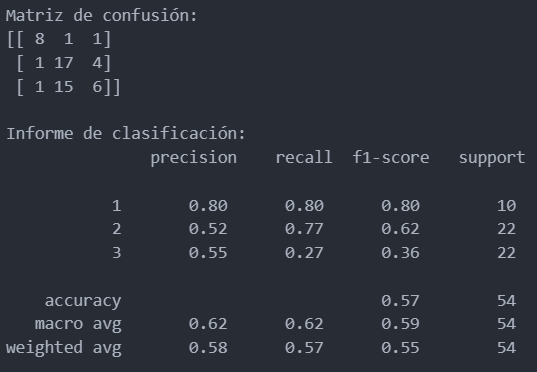


**Modelo 1: Curva ROC**<br>
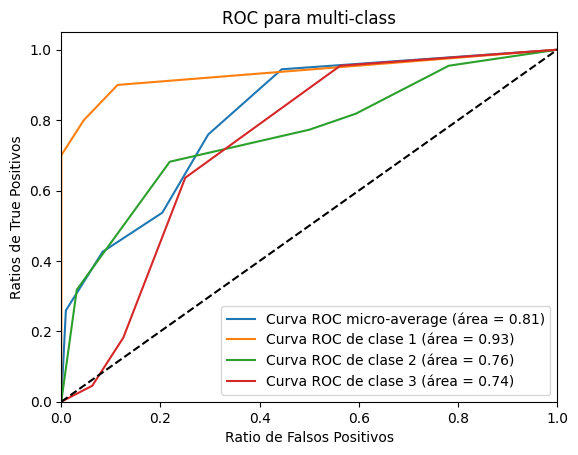


**Modelo 2: Matriz e informe**<br>
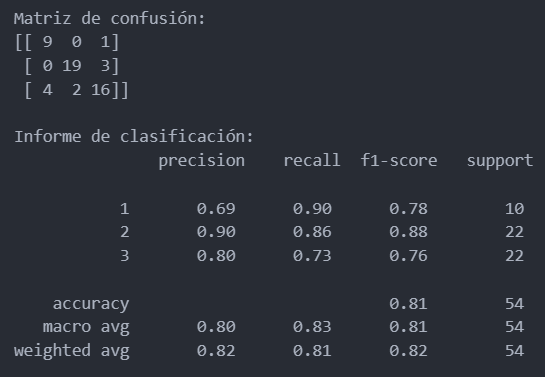


**Modelo 2: Curva ROC**<br>
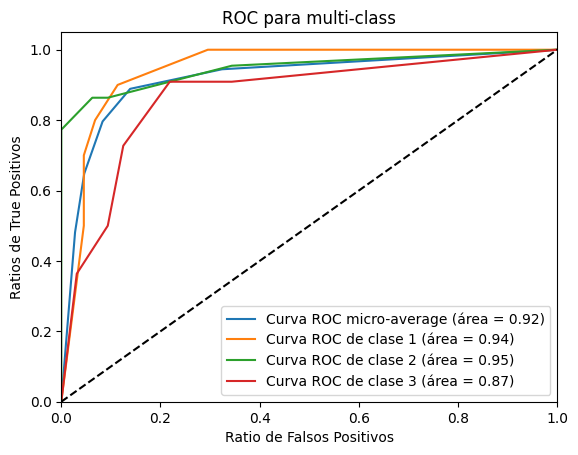

### CONCLUSIONES
Después de haber desarrollado y entrenado los dos modelos, podemos observar que el segundo modelo (KNN) es notoriamente mejor que el primero. Algunos de los datos que demuestran esto son la accuracy y la curva ROC.
 - **Accuracy:** Modelo 2: 0'81 --- Modelo 1: 0'57
 - **Curva ROC micro-average:** Modelo 2: 0'92 --- Modelo 1: 0'81

---
## PASO 3: MEJORA DEL MODELO CON ENSEMBLES

### k) Adapta el siguiente código que utiliza un random forest de 500 árboles para averiguar la importancia de cada característica y haz un listado de mayor a menor importancia. ¿Coincide con alguno de los métodos anteriores que hemos usado?

In [12]:
from sklearn.ensemble import RandomForestClassifier

carac_labels = df_vino.columns[1:]
forest = RandomForestClassifier(n_estimators=500, random_state=semilla)
forest.fit(X_train, y_train)
importancias = forest.feature_importances_
indices = np.argsort(importancias)[::-1]

In [13]:
importancia_caracteristicas_df = pd.DataFrame({
    'Característica': carac_labels[indices],
    'Importancia': importancias[indices]
})

print(importancia_caracteristicas_df)

                   Característica  Importancia
0                         Prolina     0.191249
1                Intensidad Color     0.167844
2                     Flavanoides     0.138497
3                         Alcohol     0.131310
4                      Saturación     0.100681
5   OD280/OD315 de vinos diluidos     0.092542
6                   Total Fenoles     0.057619
7                        Magnesio     0.031722
8                    Ácido Málico     0.026021
9            Alcalinidad de posos     0.022992
10                Proanticianinas     0.019347
11                          Posos     0.014358
12         No flavanoides fenoles     0.005817


Sí, coincide con un método que hemos utilizado al final de la actividad 2 de este PDF:<br>

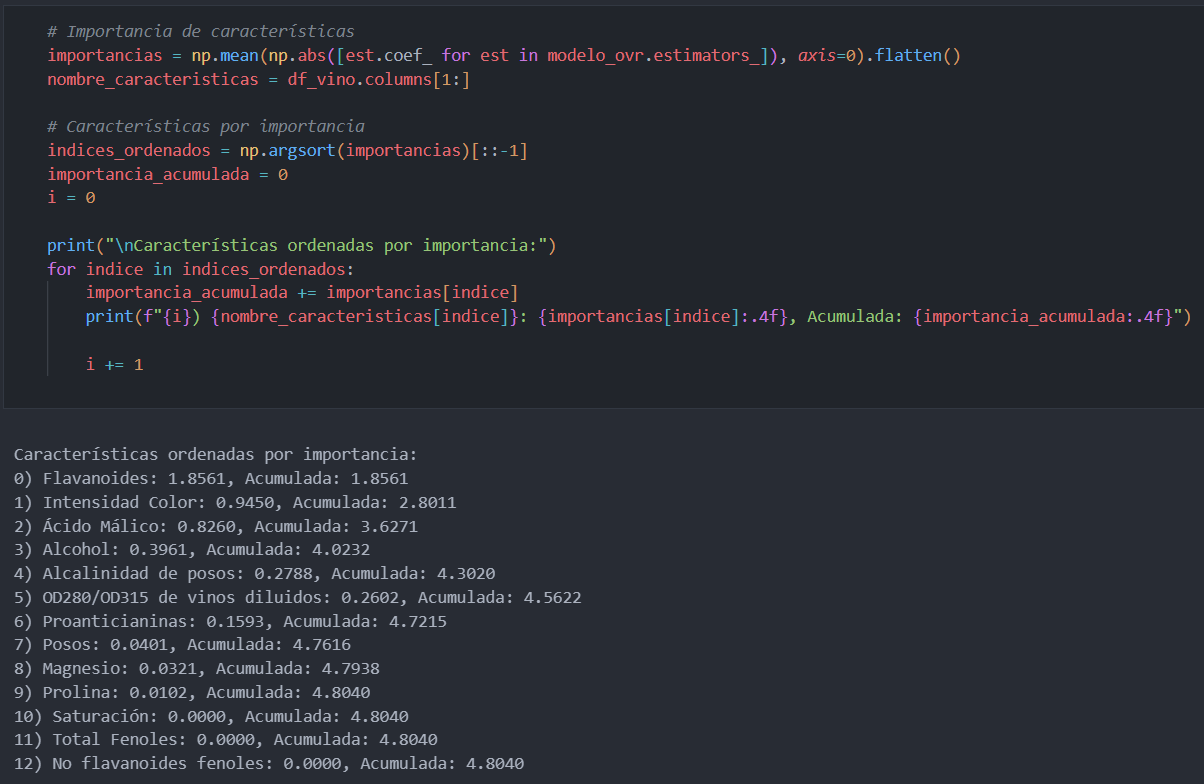

---
## PASO 4: BUSCAR EL MEJOR MODELO

Entrena estos clasificadores a ver si consigues mejorar el accuracy y el overfitting. No uses GridSearch, prefiero que uses manuealmente los modelos. Si quieres, si puedes usar validación cruzada.
 - Regresión logística.
 - SoftMax.
 - Perceptrón.
 - Bagging
 - Boosting
 - Voting de 3 modelos
 - Stacking de 3 modelos (los que quieras)

### ENTREGAR:
### e) Código de entrenamiento de modelos y captura de ejecución de test, matriz de confusión, informe, curva ROC y AUC de cada uno. Guarda el mejor modelo a un fichero.

In [14]:
import seaborn as sns

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import label_binarize

In [15]:
# Modelos
modelos = {
    "Logistic Regression": LogisticRegression(multi_class='multinomial', solver='lbfgs'),
    "Perceptron": Perceptron(),
    "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10, random_state=42),
    "Boosting": AdaBoostClassifier(n_estimators=50, random_state=42)
}

# Modelos para Voting y Stacking
modelos_base = [
    ('log_reg', LogisticRegression()),
    ('svc', SVC(probability=True)),
    ('nb', GaussianNB())
]

# Modelo: Voting classifier
modelos["Voting"] = VotingClassifier(estimators=modelos_base, voting='soft')

# Modelo: Stacking classifier
modelos["Stacking"] = StackingClassifier(estimators=modelos_base, final_estimator=LogisticRegression())

MÉTRICAS DE MODELO: Logistic Regression
Matriz de confusión:
[[ 8  1  1]
 [ 0 19  3]
 [ 3  3 16]]


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


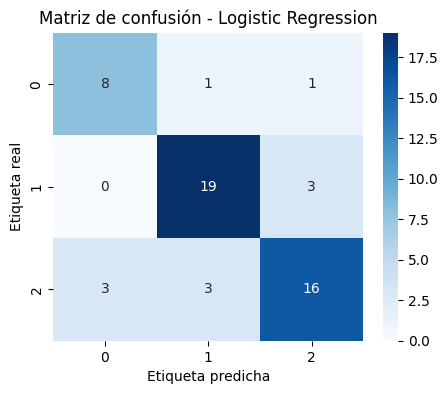

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.73      0.80      0.76        10
           2       0.83      0.86      0.84        22
           3       0.80      0.73      0.76        22

    accuracy                           0.80        54
   macro avg       0.78      0.80      0.79        54
weighted avg       0.80      0.80      0.80        54



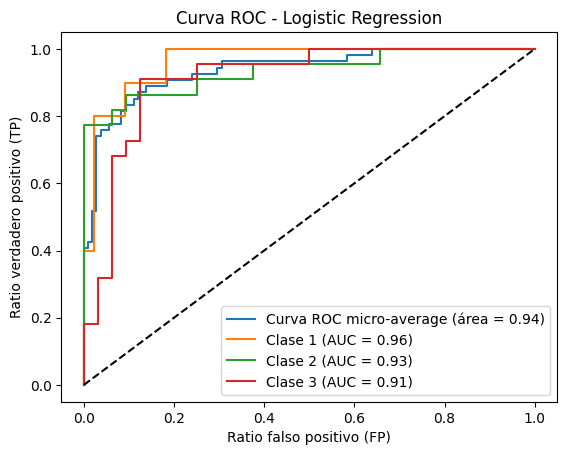

MÉTRICAS DE MODELO: Perceptron
Matriz de confusión:
[[10  0  0]
 [21  0  1]
 [20  0  2]]


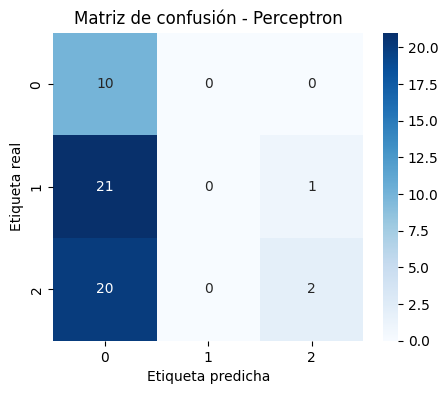

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.20      1.00      0.33        10
           2       0.00      0.00      0.00        22
           3       0.67      0.09      0.16        22

    accuracy                           0.22        54
   macro avg       0.29      0.36      0.16        54
weighted avg       0.31      0.22      0.13        54

Este modelo no dispone de curva ROC.
MÉTRICAS DE MODELO: Bagging
Matriz de confusión:
[[ 9  1  0]
 [ 1 20  1]
 [ 3  3 16]]


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

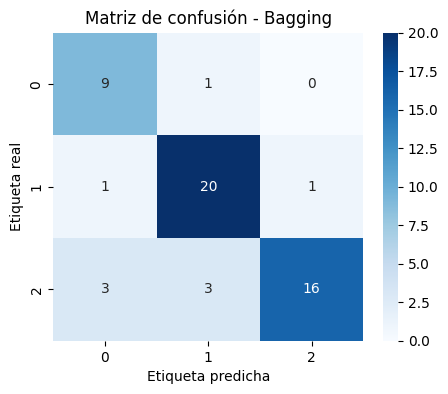

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.69      0.90      0.78        10
           2       0.83      0.91      0.87        22
           3       0.94      0.73      0.82        22

    accuracy                           0.83        54
   macro avg       0.82      0.85      0.82        54
weighted avg       0.85      0.83      0.83        54



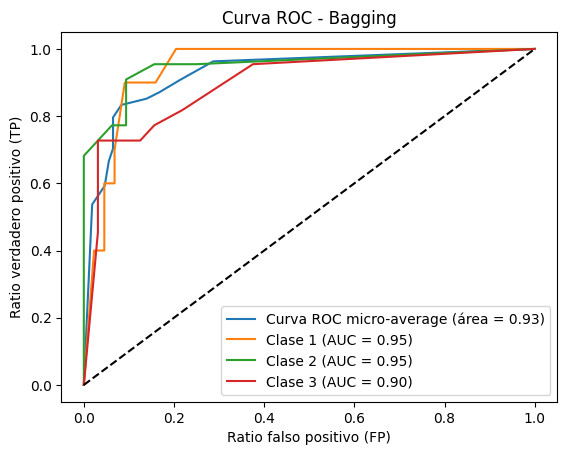

MÉTRICAS DE MODELO: Boosting
Matriz de confusión:
[[ 9  1  0]
 [ 1 19  2]
 [ 4  2 16]]


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


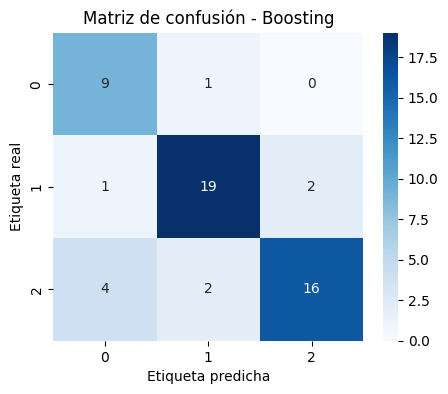

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.64      0.90      0.75        10
           2       0.86      0.86      0.86        22
           3       0.89      0.73      0.80        22

    accuracy                           0.81        54
   macro avg       0.80      0.83      0.80        54
weighted avg       0.83      0.81      0.82        54



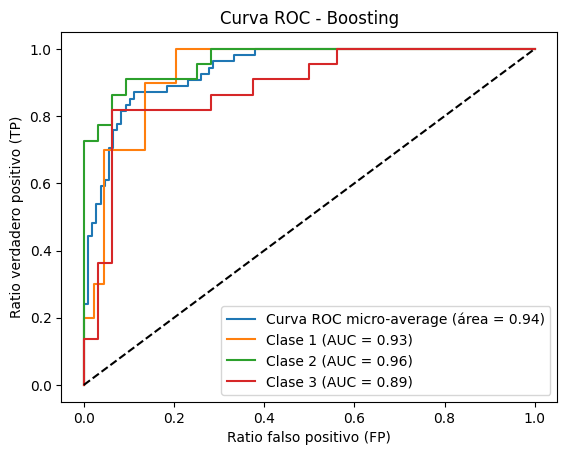

MÉTRICAS DE MODELO: Voting
Matriz de confusión:
[[ 8  0  2]
 [ 0 18  4]
 [ 3  3 16]]


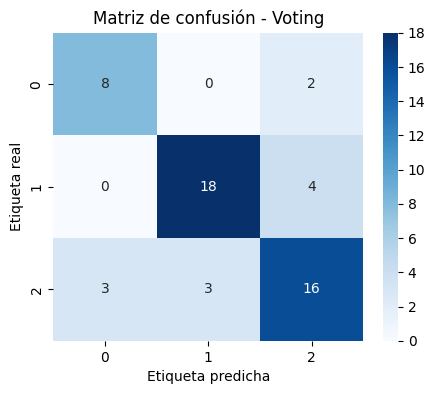

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.73      0.80      0.76        10
           2       0.86      0.82      0.84        22
           3       0.73      0.73      0.73        22

    accuracy                           0.78        54
   macro avg       0.77      0.78      0.78        54
weighted avg       0.78      0.78      0.78        54



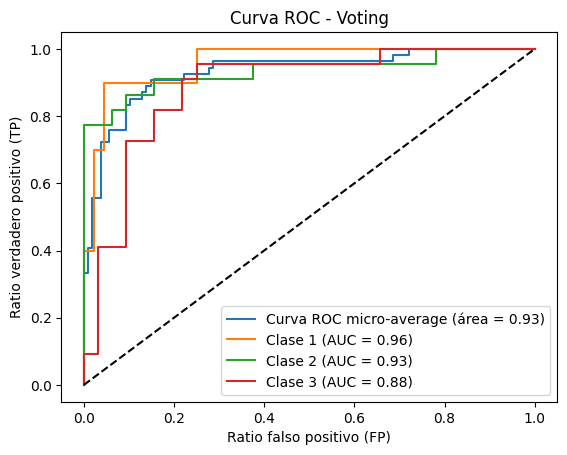

MÉTRICAS DE MODELO: Stacking
Matriz de confusión:
[[ 9  0  1]
 [ 0 19  3]
 [ 3  3 16]]


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

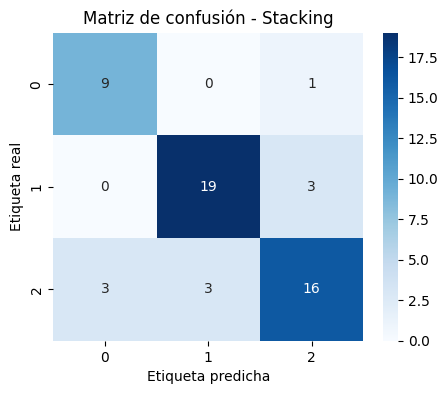

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.75      0.90      0.82        10
           2       0.86      0.86      0.86        22
           3       0.80      0.73      0.76        22

    accuracy                           0.81        54
   macro avg       0.80      0.83      0.81        54
weighted avg       0.82      0.81      0.81        54



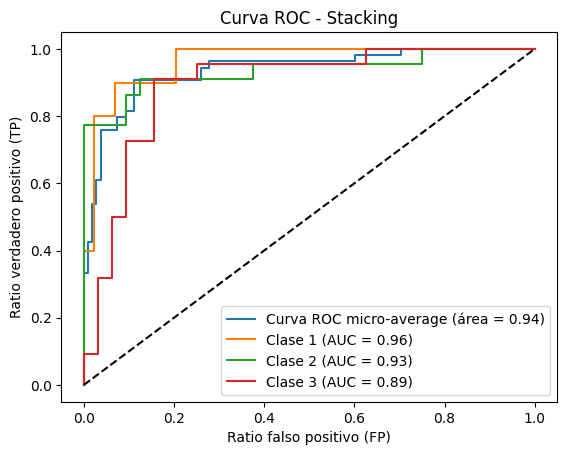

In [16]:
# Evaluación de modelos
clases = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=clases)
n_clases = len(clases)
X_train = X_train[:, k3]

for nombre, modelo in modelos.items():
    print("============================================================================")
    print("============================================================================")
    print("============================================================================")

    print(f"MÉTRICAS DE MODELO: {nombre}")
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    # Comprobar si el modelo tiene predict_proba
    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_test)
    else:
        y_score = None
    
    # Matriz de confusión
    matriz_conf = confusion_matrix(y_test, y_pred)
    print(f"Matriz de confusión:")
    print(matriz_conf)

    plt.figure(figsize=(5, 4))
    sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Etiqueta predicha')
    plt.ylabel('Etiqueta real')
    plt.title(f'Matriz de confusión - {nombre}')
    plt.show()
    
    # Reporte de clasificación
    print(f"Reporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=clases.astype(str)))
    
    # Curva ROC y AUC
    if y_score is not None and y_score.shape[1] == n_clases:
        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(n_clases):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())  # micro-medias ROC y AUC
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        
        plt.figure()
        plt.plot(
            fpr["micro"],
            tpr["micro"],
            label="Curva ROC micro-average (área = {0:0.2f})".format(roc_auc["micro"]),
        )

        for i in range(n_clases):
            plt.plot(fpr[i], tpr[i], label=f'Clase {clases[i]} (AUC = {roc_auc[i]:.2f})')

        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Ratio falso positivo (FP)')
        plt.ylabel('Ratio verdadero positivo (TP)')
        plt.title(f'Curva ROC - {nombre}')
        plt.legend()
        plt.show()

    else:
        print("Este modelo no dispone de curva ROC.")

Tras haber entrenado y analizado las métricas de todos los modelos, he observado que los 3 mejores han sido: Bagging, Boosting y Stacking.

He decidido quedarme con el modelo de Bagging debido a que ha obtenido un resultado de 0'93 en la "Curva ROC micro-average" y los mejores resultados en accuracy y macro avg:
 - Accuracy: 0'83
 - Precision (macro avg): 0'82
 - Recall (macro avg): 0'85

In [17]:
from joblib import dump

# Guardar el mejor modelo
dump(modelos["Bagging"], "mejor_modelo_bagging.joblib")
print("El mejor modelo (Bagging) ha sido guardado exitosamente como: 'mejor_modelo_bagging.joblib'")

El mejor modelo (Bagging) ha sido guardado exitosamente como: 'mejor_modelo_bagging.joblib'
